# 問卷與受試者基本資料整理

In [ ]:
#轉csv
import pandas as pd
from google.colab import files

df = pd.read_excel('/content/MUSE基本資料.xlsx', sheet_name=0)
df.to_csv('MUSE基本資料.csv', index=False, encoding='utf-8')
files.download('MUSE基本資料.csv') #下載(如果下載過，記得#掉不然他會再下載一次)

FileNotFoundError: [Errno 2] No such file or directory: '/content/MUSE基本資料.xlsx'

In [ ]:
#轉Pandas DataFrame
from IPython.display import display
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df)

,ID,年齡,性別,睡眠時間,咖啡因攝取,特殊狀況
0,6,19,女,9,0,無
1,7,21,女,9,1,剛喝完茶
2,8,20,女,7,0,無
3,9,17,女,6,1,喝茶
4,10,54,男,6,0,無
5,11,20,女,7,0,無
6,12,20,女,5,0,吃完午餐
7,13,56,男,7,0,無
8,14,15,男,7,0,無
9,15,20,女,7,0,無


In [ ]:
import pandas as pd
from IPython.display import display
file_path = '/content/MUSE基本資料.csv'
df = pd.read_csv(file_path)

descriptive_stats_rounded = df.describe().round(2)
display(descriptive_stats_rounded)

,ID,年齡,睡眠時間,咖啡因攝取
count,15.00,15.00,15.00,15.00
mean,13.00,26.67,6.73,0.33
std,4.47,14.61,1.22,0.49
min,6.00,15.00,5.00,0.00
25%,9.50,20.00,6.00,0.00
50%,13.00,20.00,7.00,0.00
75%,16.50,22.00,7.00,1.00
max,20.00,56.00,9.00,1.00


| 統計量 | 意義解釋 | 應用 |
| :--- | :--- | :--- |
| **count** | **資料筆數**：該欄位中**非空值**的數量。 | 確認資料完整性。本例中皆為 15 筆，表示無缺失值。 |
| **mean** | **算術平均值**：所有數值的總和除以筆數。 | 代表數據的**集中趨勢**。例如，平均年齡為 26.67 歲。 |
| **std** | **標準差 (Standard Deviation)**：數據分散程度的度量。 | **數值越小，資料點越集中**在平均值附近；數值越大，資料越分散。 |
| **min** | **最小值**：該欄位中的最低數值。 | 快速掌握資料的下限。例如，最年輕者為 15 歲。 |
| **25% (Q1)** | **第一四分位數**：將數據排序後，位於 **25%** 位置的數值。 | 有 25% 的資料小於或等於此數值。 |
| **50% (Q2)** | **中位數 (Median)**：將數據排序後，位於 **50%** 位置的數值。 | 不受極端值影響的集中趨勢。本例中，年齡中位數為 20.00 歲。 |
| **75% (Q3)** | **第三四分位數**：將數據排序後，位於 **75%** 位置的數值。 | 有 75% 的資料小於或等於此數值。 |
| **max** | **最大值**：該欄位中的最高數值。 | 快速掌握資料的上限。例如，最年長者為 56 歲。 |

---

### 🔍 欄位初步觀察

* **年齡 (Age)**：平均值 (26.67) 與中位數 (20.00) 存在較大差距，且標準差 (14.61) 較高，暗示年齡分佈存在極端值或右偏（有少數較年長的受試者拉高了平均值）。
* **睡眠時間 (Sleep Duration)**：平均值 (6.73) 與中位數 (7.00) 相近，標準差 (1.22) 較低，顯示睡眠時間較為集中。


# 行為資料分析

## 平均猶豫時間計算

In [ ]:
import pandas as pd

# 讀取你自己的行為資料
# df = pd.read_csv("behavior_data.csv")
df = pd.read_excel("behavior_data.xlsx")

# 檢查資料
print(df.head())

# 計算每位受試者的恐怖與柔和音樂平均
horror_mean = df["horror_time"].mean()
soft_mean = df["soft_time"].mean()

print("恐怖音樂平均猶豫時間：", horror_mean)
print("柔和音樂平均猶豫時間：", soft_mean)

   subject  horror_time  soft_time
0        6         1.06       0.40
1        7         1.89       2.05
2        8         1.85       0.73
3        9         2.20       1.97
4       10         1.91       0.91
恐怖音樂平均猶豫時間： 2.566
柔和音樂平均猶豫時間： 1.5353333333333332


## 配對 t 檢定（比較恐怖 vs 柔和音樂）

In [ ]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(df["horror_time"], df["soft_time"])

print("t 值 =", t_stat)
print("p 值 =", p_val)

t 值 = 2.1136358342299326
p 值 = 0.05297836904959717


## 繪製行為折線圖（恐怖 vs 柔和）

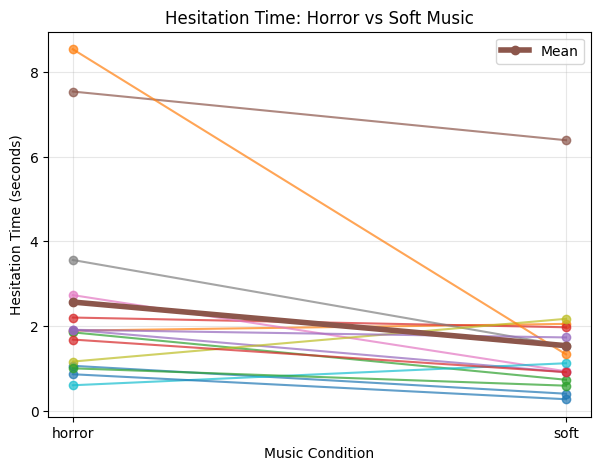

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# 每位受試者畫線
for i in range(len(df)):
    plt.plot(
        ["horror", "soft"],
        [df.loc[i, "horror_time"], df.loc[i, "soft_time"]],
        marker="o",
        alpha=0.7
    )

# 平均線
plt.plot(
    ["horror", "soft"],
    [df["horror_time"].mean(), df["soft_time"].mean()],
    marker="o",
    linewidth=4,
    label="Mean"
)

plt.title("Hesitation Time: Horror vs Soft Music")
plt.ylabel("Hesitation Time (seconds)")
plt.xlabel("Music Condition")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 腦波資料處理與分析

統計分析：
  * 重複量數 ANOVA 或配對 t **檢定，分析恐怖／柔和音樂下的腦波差異**

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import welch
import os
from google.colab import drive
import re

# --- 設定參數 ---
Fs = 256  # Muse 2 標準取樣率 (Hz)
DATA_DIR = '/content/drive/MyDrive/Muse/'
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 100)
}

def calculate_eeg_power(file_path, Fs, bands, subject_id, condition):
    """執行頻譜分析（Welch's Method）並計算絕對功率、相對功率與相對功率百分比"""
    try:
        df = pd.read_csv(file_path)
    except Exception:
        return None

    eeg_cols = ['TP9', 'AF7', 'AF8', 'TP10']
    if not all(col in df.columns for col in eeg_cols):
        return None

    eeg_data = df[eeg_cols].values

    nperseg = Fs * 2
    psd_channels = []

    for i in range(eeg_data.shape[1]):
        freqs, psd = welch(eeg_data[:, i], Fs, nperseg=nperseg, scaling='density')
        psd_channels.append(psd)

    avg_psd = np.mean(psd_channels, axis=0)

    results = {'Subject_ID': subject_id, 'Condition': condition}

    total_power_range = (freqs >= 0.5) & (freqs <= 100)
    freq_resolution = freqs[1] - freqs[0]
    total_power = np.sum(avg_psd[total_power_range]) * freq_resolution

    # 計算每個頻帶的絕對功率、相對功率與相對功率百分比
    for band_name, (low, high) in bands.items():
        band_mask = (freqs >= low) & (freqs <= high)
        band_power_sum = np.sum(avg_psd[band_mask])
        abs_p = band_power_sum * freq_resolution

        # 計算相對功率（頻段功率 / 總功率）
        relative_p = (abs_p / total_power) if total_power > 0 else 0.0

        # 計算相對功率百分比（相對功率 * 100）
        relative_p_percentage = relative_p * 100

        results[f'{band_name} Absolute Power'] = abs_p
        results[f'{band_name} Relative Power'] = relative_p  # 這是相對功率（比例）
        results[f'{band_name} Relative Power (%)'] = relative_p_percentage  # 這是相對功率百分比

    return results

# --- 主要執行區塊 ---

# *** 步驟 1: 掛載 Google Drive ***
print("--- 步驟 1: 正在掛載 Google Drive ---")
drive.mount('/content/drive')
print("掛載完成。")

# *** 步驟 2: 收集所有檔案並執行計算 ***
print(f"\n--- 步驟 2: 正在收集 {DATA_DIR} 中的檔案並分析 ---")
if not os.path.isdir(DATA_DIR):
    print(f"\n[嚴重錯誤] Google Drive 路徑不存在: {DATA_DIR}")
    exit()

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv') and f.startswith('EEG_data')]
results_list = []

for file_name in all_files:
    file_path = os.path.join(DATA_DIR, file_name)

    # 擷取受試者 ID
    match = re.search(r'EEG_data(\d+)', file_name)
    subject_id = int(match.group(1)) if match else None

    # 判斷情境
    if '_1.csv' in file_name:
        condition = 'Horror (恐怖)'
    elif '_2.csv' in file_name:
        condition = 'Calm (柔和)'
    else:
        continue

    if subject_id is not None:
        result = calculate_eeg_power(file_path, Fs, bands, subject_id, condition)
        if result:
            results_list.append(result)

# *** 步驟 3: 彙整結果並顯示每位受試者的絕對功率、相對功率和相對功率百分比 ***
all_subjects_df = pd.DataFrame(results_list).drop_duplicates(subset=['Subject_ID', 'Condition'], keep='last')
N_subjects_unique = len(all_subjects_df['Subject_ID'].unique()) if 'Subject_ID' in all_subjects_df.columns else 0

if all_subjects_df.empty:
    print("\n--- 錯誤：沒有檔案被成功讀取或處理。請檢查檔案。---")
    exit()
else:
    print(f"\n--- 步驟 3: 功率計算完成，N={N_subjects_unique} ---")

    # 選擇需要的欄位：Subject_ID, Condition, 所有 Absolute Power, Relative Power, Relative Power (%) 欄位
    power_cols = [col for col in all_subjects_df.columns if 'Absolute Power' in col]
    rel_power_cols = [col for col in all_subjects_df.columns if 'Relative Power' in col]
    rel_percentage_cols = [col for col in all_subjects_df.columns if 'Relative Power (%)' in col]
    output_cols = ['Subject_ID', 'Condition'] + power_cols + rel_power_cols + rel_percentage_cols

    # 顯示最終結果
    individual_power_df = all_subjects_df[output_cols]
    print("\n==================================================================")
    print("📈 最終輸出：每位受試者在兩種情境下的絕對功率、相對功率與相對功率百分比 (%)")
    print("==================================================================")
    print(individual_power_df.to_string(index=False, float_format="%.4f"))

    print("\n--- 程式運行完畢，結果已內嵌顯示。---")


--- 步驟 1: 正在掛載 Google Drive ---
Mounted at /content/drive
掛載完成。

--- 步驟 2: 正在收集 /content/drive/MyDrive/Muse/ 中的檔案並分析 ---

--- 步驟 3: 功率計算完成，N=15 ---

📈 最終輸出：每位受試者在兩種情境下的絕對功率、相對功率與相對功率百分比 (%)
 Subject_ID   Condition  Delta Absolute Power  Theta Absolute Power  Alpha Absolute Power  Beta Absolute Power  Gamma Absolute Power  Delta Relative Power  Delta Relative Power (%)  Theta Relative Power  Theta Relative Power (%)  Alpha Relative Power  Alpha Relative Power (%)  Beta Relative Power  Beta Relative Power (%)  Gamma Relative Power  Gamma Relative Power (%)  Delta Relative Power (%)  Theta Relative Power (%)  Alpha Relative Power (%)  Beta Relative Power (%)  Gamma Relative Power (%)
          6 Horror (恐怖)            13716.9939             2842.6554             1213.7933            1306.8974             2426.6343                0.6594                   65.9383                0.1366                   13.6648                0.0583                    5.8348               0.0628             

In [ ]:
# 需要安裝 openpyxl 庫來處理 Excel 檔案
# 在 Colab 中執行安裝
!pip install openpyxl

# 儲存結果到 Excel 檔案
output_file = "/content/drive/MyDrive/Muse/results.xlsx"  # 設定儲存的路徑
all_subjects_df.to_excel(output_file, index=False, engine='openpyxl')  # 儲存為 Excel 檔案

print(f"\n結果已成功儲存至 {output_file}")



結果已成功儲存至 /content/drive/MyDrive/Muse/results.xlsx


In [ ]:
# Install pingouin library at the very beginning to ensure it's available
!pip install pingouin

import pandas as pd
import numpy as np
from scipy.signal import welch
from scipy import stats
import os
from google.colab import drive
import re
import pingouin as pg # Now pingouin should be importable after installation

# --- 從 REA16XJwO7_o 整合的資料處理部分 --- Start
# --- 設定參數 ---
Fs = 256  # Muse 2 標準取樣率 (Hz)
DATA_DIR = '/content/drive/MyDrive/Muse/'
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 100)
}

def calculate_eeg_power(file_path, Fs, bands, subject_id, condition):
    """執行頻譜分析（Welch's Method）並計算絕對功率、相對功率與相對功率百分比"""
    try:
        df = pd.read_csv(file_path)
    except Exception:
        return None

    eeg_cols = ['TP9', 'AF7', 'AF8', 'TP10']
    if not all(col in df.columns for col in eeg_cols):
        return None

    eeg_data = df[eeg_cols].values

    nperseg = Fs * 2
    psd_channels = []

    for i in range(eeg_data.shape[1]):
        freqs, psd = welch(eeg_data[:, i], Fs, nperseg=nperseg, scaling='density')
        psd_channels.append(psd)

    avg_psd = np.mean(psd_channels, axis=0)

    results = {'Subject_ID': subject_id, 'Condition': condition}

    total_power_range = (freqs >= 0.5) & (freqs <= 100)
    freq_resolution = freqs[1] - freqs[0]
    total_power = np.sum(avg_psd[total_power_range]) * freq_resolution

    # 計算每個頻帶的絕對功率、相對功率與相對功率百分比
    for band_name, (low, high) in bands.items():
        band_mask = (freqs >= low) & (freqs <= high)
        band_power_sum = np.sum(avg_psd[band_mask])
        abs_p = band_power_sum * freq_resolution

        # 計算相對功率（比例）
        relative_p = (abs_p / total_power) if total_power > 0 else 0.0

        # 計算相對功率百分比
        relative_p_percentage = relative_p * 100

        results[f'{band_name} Absolute Power'] = abs_p
        results[f'{band_name} Relative Power'] = relative_p  # 這是相對功率（比例）
        results[f'{band_name} Relative Power (%)'] = relative_p_percentage  # 這是相對功率百分比

    return results

# --- 主要執行區塊 ---

# *** 步驟 1: 掛載 Google Drive ***
print("--- 步驟 1: 正在掛載 Google Drive ---")
drive.mount('/content/drive')
print("掛載完成。")

# *** 步驟 2: 收集所有檔案並執行計算 ***
print(f"\n--- 步驟 2: 正在收集 {DATA_DIR} 中的檔案並分析 ---")
if not os.path.isdir(DATA_DIR):
    print(f"\n[嚴重錯誤] Google Drive 路徑不存在: {DATA_DIR}")
    exit()

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv') and f.startswith('EEG_data')]
results_list = []

for file_name in all_files:
    file_path = os.path.join(DATA_DIR, file_name)

    # 擷取受試者 ID
    match = re.search(r'EEG_data(\d+)', file_name)
    subject_id = int(match.group(1)) if match else None

    # 判斷情境
    if '_1.csv' in file_name:
        condition = 'Horror (恐怖)'
    elif '_2.csv' in file_name:
        condition = 'Calm (柔和)' # 使用 'Calm (柔和)' 與 REA16XJwO7_o 輸出一致
    else:
        continue

    if subject_id is not None:
        result = calculate_eeg_power(file_path, Fs, bands, subject_id, condition)
        if result:
            results_list.append(result)

# *** 步驟 3: 彙整結果創建 all_subjects_df ***
all_subjects_df = pd.DataFrame(results_list).drop_duplicates(subset=['Subject_ID', 'Condition'], keep='last')
N_subjects_unique = len(all_subjects_df['Subject_ID'].unique()) if 'Subject_ID' in all_subjects_df.columns else 0

if all_subjects_df.empty:
    print("\n--- 錯誤：沒有檔案被成功讀取或處理。請檢查檔案。---")
    exit()
else:
    print(f"\n--- 步驟 3: 功率計算完成，N={N_subjects_unique} ---")
# --- 從 REA16XJwO7_o 整合的資料處理部分 --- End

# 1. 載入數據檔案
# 修正：直接使用之前計算好的 all_subjects_df DataFrame
df_for_analysis = all_subjects_df.copy() # 重命名避免與函數內df衝突

# 2. 定義分析所需的欄位名稱
subject_col = 'Subject_ID'
condition_col = 'Condition'
relative_power_cols = [
    'Delta Relative Power (%)',
    'Theta Relative Power (%)',
    'Alpha Relative Power (%)',
    'Beta Relative Power (%)',
    'Gamma Relative Power (%)'
]

# 3. 過濾數據並準備進行分析
df_analysis = df_for_analysis[[subject_col, condition_col] + relative_power_cols].copy()


# =======================================================
#                       輸出 1: 配對 t 檢定
# =======================================================

# 將數據轉換為寬格式 (Wide format) 以便進行配對比較
df_wide = df_analysis.pivot(index=subject_col, columns=condition_col, values=relative_power_cols)

t_test_results = []
# 確保僅使用擁有兩種情境完整數據的受試者
N_paired = len(df_wide.dropna().index)

print(f"\n--- 輸出 1: 配對 t 檢定結果 (Paired N={N_paired}) ---")
for col in relative_power_cols:
    try:
        # 提取兩組條件的數據
        # 修正：根據Condition名稱 'Horror (恐怖)' 和 'Calm (柔和)'
        horror_data = df_wide[(col, 'Horror (恐怖)')].dropna()
        calm_data = df_wide[(col, 'Calm (柔和)')].dropna()

        # 執行配對 t 檢定
        if len(horror_data) == len(calm_data) and len(horror_data) >= 2:
            t_stat, p_value = stats.ttest_rel(horror_data, calm_data)
        else:
            t_stat, p_value = np.nan, np.nan

        t_test_results.append({
            'Frequency Band': col.replace(' Relative Power (%)', ''),
            't_statistic': t_stat,
            'p_value': p_value
        })
    except Exception as e:
        t_test_results.append({
            'Frequency Band': col.replace(' Relative Power (%)', ''),
            't_statistic': np.nan,
            'p_value': np.nan
        })

t_test_df = pd.DataFrame(t_test_results)
print(t_test_df.to_string(index=False, float_format="%.4f"))


# =======================================================
#                       輸出 2: 重複量數 ANOVA
# =======================================================

# 將數據轉換為長格式 (Long format) 以便進行 ANOVA
df_long = df_analysis.melt(
    id_vars=[subject_col, condition_col],
    value_vars=relative_power_cols,
    var_name='Frequency',
    value_name='Power'
)
df_long['Frequency'] = df_long['Frequency'].str.replace(' Relative Power (%)', '', regex=False)

print("\n--- 輸出 2: 重複量數 ANOVA 結果 (情境 x 頻帶交互作用) ---")
try:
    # pingouin should be available now
    # 執行 2 (Condition) x 5 (Frequency) 雙因素重複量數 ANOVA
    aov_results = pg.rm_anova(
        data=df_long,
        dv='Power',
        within=['Condition', 'Frequency'],
        subject=subject_col,
        correction=True, # 應用球形檢定校正
        detailed=True
    )
    # 格式化輸出
    aov_results = aov_results.set_index('Source').round(4)
    print(aov_results[['F', 'p-unc', 'p-GG-hf', 'np2']].to_string())
    print("\n[註]: p-GG-hf 是校正後的 P 值 (常用於 EEG)。np2 是效果量 (Effect Size)。")

except Exception as e:
    print(f"[錯誤] 執行 pingouin.rm_anova 時發生錯誤: {e}")
    print("請檢查數據和函式庫安裝。")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 16.0 MB/s eta 0:00:00
--- 步驟 1: 正在掛載 Google Drive ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
掛載完成。

--- 步驟 2: 正在收集 /content/drive/MyDrive/Muse/ 中的檔案並分析 ---

--- 步驟 3: 功率計算完成，N=15 ---

--- 輸出 1: 配對 t 檢定結果 (Paired N=15) ---
Frequency Band  t_statistic  p_value
         Delta       2.2787   0.0389
         Theta      -0.8797   0.3939
         Alpha      -0.8410   0.4145
          Beta      -2.2488   0.0411
         Gamma      -1.2012   0.2496

--- 輸出 2: 重複量數 ANOVA 結果 (情境 x 頻帶交互作用) ---
[錯誤] 執行 pingouin.rm_anova 時發生錯誤: "['p-GG-hf', 'np2'] not in index"
請檢查數據和函式庫安裝。


/usr/local/lib/python3.12/dist-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/usr/local/lib/python3.12/dist-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [ ]:
import pandas as pd
import pingouin as pg

# 假設您已經讀取了處理過的資料，並將其存儲在 'processed_results.xlsx' 中
data = pd.read_excel('/content/drive/MyDrive/Muse/results.xlsx')

# 轉換為長格式，以便進行 ANOVA 分析
anova_data = data.melt(id_vars=['Subject_ID', 'Condition'], value_vars=['Delta Relative Power', 'Theta Relative Power', 'Alpha Relative Power', 'Beta Relative Power', 'Gamma Relative Power'],
                       var_name='Frequency Band', value_name='Relative Power')

# 確保資料格式正確，進行重複量數 ANOVA
aov_results = pg.rm_anova(data=anova_data, dv='Relative Power', within=['Condition', 'Frequency Band'], subject='Subject_ID')

# 顯示 ANOVA 結果
print(aov_results)


                       Source        SS  ddof1  ddof2        MS          F  \
0                   Condition  0.000018      1     14  0.000018   0.504598   
1              Frequency Band  5.508409      4     56  1.377102  13.863038   
2  Condition * Frequency Band  0.024481      4     56  0.006120   3.052458   

          p-unc  p-GG-corr       ng2       eps  
0  4.891514e-01   0.489151  0.000003  1.000000  
1  6.380901e-08   0.002020  0.492472  0.258111  
2  2.402017e-02   0.062986  0.004294  0.501794  


/usr/local/lib/python3.12/dist-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/usr/local/lib/python3.12/dist-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


根據 配對 t 檢定 和 ANOVA 結果，我們可以得出以下結論：

恐怖音樂和柔和音樂在某些頻帶（如 Delta 和 Beta）上有顯著差異，但是對於其他頻帶（如 Theta、Alpha 和 Gamma），這兩種音樂條件之間的差異不顯著。

音樂條件本身的影響較小（p = 0.4892），但頻帶對腦波功率的影響顯著，這表明不同頻帶在腦波活動中起著更重要的作用。

音樂條件和頻帶之間的交互作用也顯示出顯著性，這意味著音樂條件對腦波的影響會因為頻帶的不同而有所不同。

總結來說，音樂情境（恐怖 vs. 柔和音樂）確實會影響一些頻帶的腦波活動（如 Delta 和 Beta），但其影響並不是在所有頻帶上都顯著。

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================
# 1. 資料準備與計算 (Data Preparation)
# =========================================

# --- 【Fix 1】Use relative_power_cols for calculations to match the y-axis (Mean Relative Power (%)) ---
# Calculate the mean relative power for each band and condition
average_power_df = all_subjects_df.groupby('Condition')[relative_power_cols].mean().reset_index()

# Define standard error (SEM) calculation function
sem_func = lambda series: series.dropna().std() / np.sqrt(len(series.dropna())) if len(series.dropna()) > 1 else np.nan
# Calculate SEM for relative power for each band and condition
sem_power_df = all_subjects_df.groupby('Condition')[relative_power_cols].apply(sem_func).reset_index()

# Prepare data for plotting (Melt)
plot_data_df = average_power_df.melt(id_vars='Condition', value_vars=relative_power_cols, var_name='Frequency Band', value_name='Mean Relative Power (%)')
sem_power_df_melted = sem_power_df.melt(id_vars='Condition', value_vars=relative_power_cols, var_name='Frequency Band', value_name='SEM')

# Clean band names (remove suffix for easier matching with band_order)
plot_data_df['Frequency Band'] = plot_data_df['Frequency Band'].str.replace(' Relative Power (%)', '', regex=False)
sem_power_df_melted['Frequency Band'] = sem_power_df_melted['Frequency Band'].str.replace(' Relative Power (%)', '', regex=False)

# Merge Mean and SEM data
plot_data_df = pd.merge(plot_data_df, sem_power_df_melted, on=['Condition', 'Frequency Band'])

# --- 【關鍵修改 1】將資料中的中文情境名稱改為英文 ---
# 這樣圖表的 Legend (圖例) 和後續篩選才會是英文
plot_data_df['Condition'] = plot_data_df['Condition'].replace({
    'Horror (恐怖)': 'Horror',
    'Calm (柔和)': 'Calm'
})

# =========================================
# 2. 統計標註準備 (Statistical Annotation Prep)
# =========================================

# Statistical significance annotations (based on p-value)
stat_df_plot = t_test_df[['Frequency Band', 't_statistic', 'p_value']].copy() # Already uses t_test_df
stat_df_plot.rename(columns={'t_statistic': 'N_paired'}, inplace=True) # Rename t_statistic to N_paired for consistency
stat_df_plot['N_paired'] = N_paired # Use the global N_paired for plotting

def get_sig_label(p):
    if pd.isna(p) or p >= 0.05:
        return 'n.s.'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'n.s.'

stat_df_plot['Sig_Label'] = stat_df_plot['p_value'].apply(get_sig_label)
# This merge should now work correctly because both 'Frequency Band' columns will contain 'Delta', 'Theta', etc.
plot_data_df = pd.merge(plot_data_df, stat_df_plot, on='Frequency Band', how='left')

# Find max power to set annotation position
max_power_per_band = plot_data_df.groupby('Frequency Band')['Mean Relative Power (%)'].max().reset_index()
max_power_per_band.columns = ['Frequency Band', 'Max_Power']
plot_data_df = pd.merge(plot_data_df, max_power_per_band, on='Frequency Band', how='left')

# Set Y-axis annotation height
max_overall_power = plot_data_df['Mean Relative Power (%)'].max()
plot_data_df['Y_position'] = plot_data_df['Max_Power'] + max_overall_power * 0.05

# Remove null values
plot_data_df = plot_data_df.dropna(subset=['Mean Relative Power (%)'])

# =========================================
# 3. 繪圖 (Plotting in English)
# =========================================

band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# --- 【關鍵修改 2】移除中文字型設定，使用通用設定 ---
plt.rcParams.update({'font.size': 12, 'axes.unicode_minus': False})

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bar chart
sns.barplot(
    x='Frequency Band',
    y='Mean Relative Power (%)',
    hue='Condition',
    data=plot_data_df,
    capsize=0.1,
    order=band_order,
    ax=ax,
    palette="viridis" # Optional: add color scheme for better aesthetics
)

# Draw error bars (SEM)
bar_positions = np.arange(len(band_order))
for i, band in enumerate(band_order):
    # Filter band_data for the current band
    band_data_filtered = plot_data_df[plot_data_df['Frequency Band'] == band]

    # Check if band_data_filtered is empty before proceeding
    if band_data_filtered.empty:
        # This band might not exist in the filtered plot_data_df, skip it
        continue

    # Calculate offset for bar chart centers
    horror_x = bar_positions[i] - 0.2
    calm_x = bar_positions[i] + 0.2

    # Draw Horror error bar
    horror_data = band_data_filtered[band_data_filtered['Condition'] == 'Horror']
    if not horror_data.empty and not pd.isna(horror_data['SEM'].iloc[0]):
        mean = horror_data['Mean Relative Power (%)'].iloc[0]
        sem = horror_data['SEM'].iloc[0]
        ax.errorbar(horror_x, mean, yerr=sem, fmt='none', c='black', capsize=5)

    # Draw Calm error bar
    calm_data = band_data_filtered[band_data_filtered['Condition'] == 'Calm']
    if not calm_data.empty and not pd.isna(calm_data['SEM'].iloc[0]):
        mean = calm_data['Mean Relative Power (%)'].iloc[0]
        sem = calm_data['SEM'].iloc[0]
        ax.errorbar(calm_x, mean, yerr=sem, fmt='none', c='black', capsize=5)

    # Display significance markers
    # Use band_data_filtered here to ensure we are using the filtered data
    marker_data = band_data_filtered.iloc[0] # Get the first row for this band, should not be empty now
    sig_label = marker_data['Sig_Label']
    y_pos = marker_data['Y_position']
    N_paired_val = marker_data['N_paired']

    # If significant, draw line and asterisks
    if sig_label != 'n.s.':
        ax.plot([horror_x, calm_x], [y_pos * 0.99, y_pos * 0.99], c='black', lw=1.0)
        ax.text(i, y_pos, sig_label, ha='center', va='bottom', fontsize=14, fontweight='bold')

    # Display paired sample size - finely tuned position to avoid overlapping with asterisks
    text_offset = max_overall_power * 0.02 if sig_label != 'n.s.' else 0
    ax.text(i, y_pos * 1.05 + text_offset, f'Paired N={int(N_paired_val)}',
            ha='center', va='bottom', fontsize=9, color='gray')

# --- 【關鍵修改 4】設置全英文標題與標籤 ---
ax.set_title(f'Comparison of Mean Relative Power (N={N_subjects_unique} Subjects)', fontsize=14)
ax.set_xlabel('Frequency Band', fontsize=12)
ax.set_ylabel('Mean Relative Power (%)', fontsize=12)
ax.legend(title='Condition', loc='upper right')

# Adjust Y-axis range to accommodate annotations
ax.set_ylim(0, plot_data_df['Y_position'].max() * 1.15)

plt.tight_layout()
plt.show()

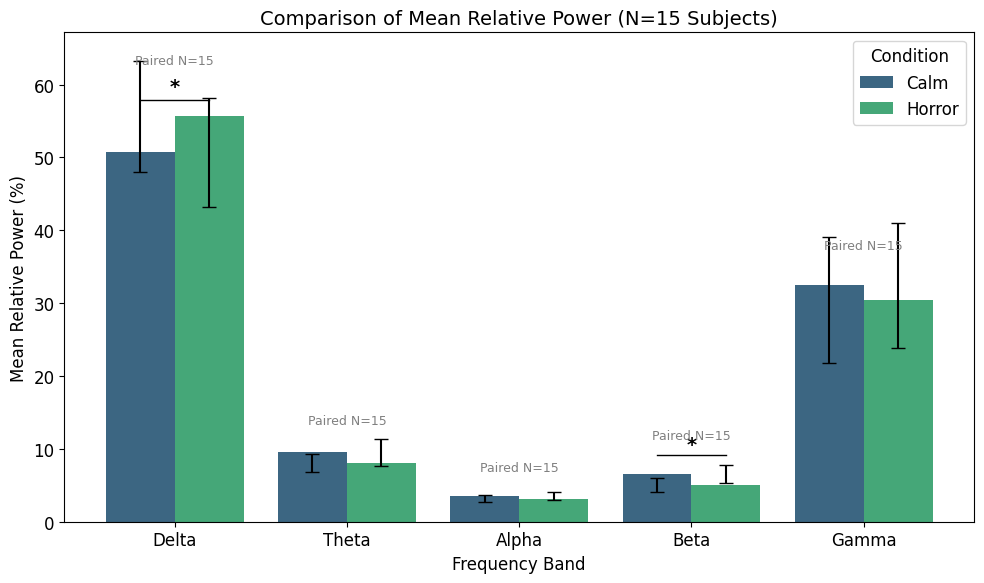

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================
# 1. 資料準備與計算 (Data Preparation)
# =========================================

# --- 【Fix 1】Use relative_power_cols for calculations to match the y-axis (Mean Relative Power (%)) ---
# Calculate the mean relative power for each band and condition
average_power_df = all_subjects_df.groupby('Condition')[relative_power_cols].mean().reset_index()

# Define standard error (SEM) calculation function
sem_func = lambda series: series.dropna().std() / np.sqrt(len(series.dropna())) if len(series.dropna()) > 1 else np.nan
# Calculate SEM for relative power for each band and condition
sem_power_df = all_subjects_df.groupby('Condition')[relative_power_cols].apply(sem_func).reset_index()

# Prepare data for plotting (Melt)
plot_data_df = average_power_df.melt(id_vars='Condition', value_vars=relative_power_cols, var_name='Frequency Band', value_name='Mean Relative Power (%)')
sem_power_df_melted = sem_power_df.melt(id_vars='Condition', value_vars=relative_power_cols, var_name='Frequency Band', value_name='SEM')

# Clean band names (remove suffix for easier matching with band_order)
plot_data_df['Frequency Band'] = plot_data_df['Frequency Band'].str.replace(' Relative Power (%)', '', regex=False)
sem_power_df_melted['Frequency Band'] = sem_power_df_melted['Frequency Band'].str.replace(' Relative Power (%)', '', regex=False)

# Merge Mean and SEM data
plot_data_df = pd.merge(plot_data_df, sem_power_df_melted, on=['Condition', 'Frequency Band'])

# --- 【關鍵修改 1】將資料中的中文情境名稱改為英文 ---
# 這樣圖表的 Legend (圖例) 和後續篩選才會是英文
plot_data_df['Condition'] = plot_data_df['Condition'].replace({
    'Horror (恐怖)': 'Horror',
    'Calm (柔和)': 'Calm'
})

# =========================================
# 2. 統計標註準備 (Statistical Annotation Prep)
# =========================================

# Statistical significance annotations (based on p-value)
stat_df_plot = t_test_df[['Frequency Band', 't_statistic', 'p_value']].copy() # Already uses t_test_df
stat_df_plot.rename(columns={'t_statistic': 'N_paired'}, inplace=True) # Rename t_statistic to N_paired for consistency
stat_df_plot['N_paired'] = N_paired # Use the global N_paired for plotting

def get_sig_label(p):
    if pd.isna(p) or p >= 0.05:
        return 'n.s.'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'n.s.'

stat_df_plot['Sig_Label'] = stat_df_plot['p_value'].apply(get_sig_label)
# This merge should now work correctly because both 'Frequency Band' columns will contain 'Delta', 'Theta', etc.
plot_data_df = pd.merge(plot_data_df, stat_df_plot, on='Frequency Band', how='left')

# Find max power to set annotation position
max_power_per_band = plot_data_df.groupby('Frequency Band')['Mean Relative Power (%)'].max().reset_index()
max_power_per_band.columns = ['Frequency Band', 'Max_Power']
plot_data_df = pd.merge(plot_data_df, max_power_per_band, on='Frequency Band', how='left')

# Set Y-axis annotation height
max_overall_power = plot_data_df['Mean Relative Power (%)'].max()
plot_data_df['Y_position'] = plot_data_df['Max_Power'] + max_overall_power * 0.05

# Remove null values
plot_data_df = plot_data_df.dropna(subset=['Mean Relative Power (%)'])

# =========================================
# 3. 繪圖 (Plotting in English)
# =========================================

band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# --- 【關鍵修改 2】移除中文字型設定，使用通用設定 ---
plt.rcParams.update({'font.size': 12, 'axes.unicode_minus': False})

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bar chart
sns.barplot(
    x='Frequency Band',
    y='Mean Relative Power (%)',
    hue='Condition',
    data=plot_data_df,
    capsize=0.1,
    order=band_order,
    ax=ax,
    palette="viridis" # Optional: add color scheme for better aesthetics
)

# Draw error bars (SEM)
bar_positions = np.arange(len(band_order))
for i, band in enumerate(band_order):
    # Filter band_data for the current band
    band_data_filtered = plot_data_df[plot_data_df['Frequency Band'] == band]

    # Check if band_data_filtered is empty before proceeding
    if band_data_filtered.empty:
        # This band might not exist in the filtered plot_data_df, skip it
        continue

    # Calculate offset for bar chart centers
    horror_x = bar_positions[i] - 0.2
    calm_x = bar_positions[i] + 0.2

    # Draw Horror error bar
    horror_data = band_data_filtered[band_data_filtered['Condition'] == 'Horror']
    if not horror_data.empty and not pd.isna(horror_data['SEM'].iloc[0]):
        mean = horror_data['Mean Relative Power (%)'].iloc[0]
        sem = horror_data['SEM'].iloc[0]
        ax.errorbar(horror_x, mean, yerr=sem, fmt='none', c='black', capsize=5)

    # Draw Calm error bar
    calm_data = band_data_filtered[band_data_filtered['Condition'] == 'Calm']
    if not calm_data.empty and not pd.isna(calm_data['SEM'].iloc[0]):
        mean = calm_data['Mean Relative Power (%)'].iloc[0]
        sem = calm_data['SEM'].iloc[0]
        ax.errorbar(calm_x, mean, yerr=sem, fmt='none', c='black', capsize=5)

    # Display significance markers
    # Use band_data_filtered here to ensure we are using the filtered data
    marker_data = band_data_filtered.iloc[0] # Get the first row for this band, should not be empty now
    sig_label = marker_data['Sig_Label']
    y_pos = marker_data['Y_position']
    N_paired_val = marker_data['N_paired']

    # If significant, draw line and asterisks
    if sig_label != 'n.s.':
        ax.plot([horror_x, calm_x], [y_pos * 0.99, y_pos * 0.99], c='black', lw=1.0)
        ax.text(i, y_pos, sig_label, ha='center', va='bottom', fontsize=14, fontweight='bold')

    # Display paired sample size - finely tuned position to avoid overlapping with asterisks
    text_offset = max_overall_power * 0.02 if sig_label != 'n.s.' else 0
    ax.text(i, y_pos * 1.05 + text_offset, f'Paired N={int(N_paired_val)}',
            ha='center', va='bottom', fontsize=9, color='gray')

# --- 【關鍵修改 4】設置全英文標題與標籤 ---
ax.set_title(f'Comparison of Mean Relative Power (N={N_subjects_unique} Subjects)', fontsize=14)
ax.set_xlabel('Frequency Band', fontsize=12)
ax.set_ylabel('Mean Relative Power (%)', fontsize=12)
ax.legend(title='Condition', loc='upper right')

# Adjust Y-axis range to accommodate annotations
ax.set_ylim(0, plot_data_df['Y_position'].max() * 1.15)

plt.tight_layout()
plt.show()

# 相關分析與整合圖表

In [ ]:
import pandas as pd

# Load the datasets
results_df = pd.read_excel('results.xlsx', sheet_name='Sheet1')
demographics_df = pd.read_csv('MUSE基本資料.csv')
behavior_df = pd.read_excel('behavior_data.xlsx', sheet_name='工作表1')

# Display head and info for each to understand structure
print("Results Head:")
print(results_df.head())
print("\nResults Info:")
print(results_df.info())

print("\nDemographics Head:")
print(demographics_df.head())
print("\nDemographics Info:")
print(demographics_df.info())

print("\nBehavior Head:")
print(behavior_df.head())
print("\nBehavior Info:")
print(behavior_df.info())

Results Head:
   Subject_ID    Condition  Delta Absolute Power  Delta Relative Power  \
0           6  Horror (恐怖)          13716.993929              0.659383   
1           6    Calm (柔和)          25142.686990              0.537825   
2           7  Horror (恐怖)          19312.055689              0.855067   
3           7    Calm (柔和)          12898.493446              0.711366   
4           8    Calm (柔和)           3509.463538              0.709447   

   Delta Relative Power (%)  Theta Absolute Power  Theta Relative Power  \
0                 65.938293           2842.655400              0.136648   
1                 53.782497           6357.796245              0.135999   
2                 85.506698           2595.362585              0.114913   
3                 71.136565           3063.376408              0.168948   
4                 70.944682            195.948976              0.039612   

   Theta Relative Power (%)  Alpha Absolute Power  Alpha Relative Power  \
0              

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# --- Data Processing ---

# 1. Clean Condition names
results_df['Condition'] = results_df['Condition'].apply(lambda x: 'Horror' if 'Horror' in x else 'Calm')

# 2. Pivot EEG data to wide format (Subject x Variables)
# We want columns like 'Delta Absolute Power_Horror', 'Delta Absolute Power_Calm'
eeg_wide = results_df.pivot(index='Subject_ID', columns='Condition')
# Flatten MultiIndex columns
eeg_wide.columns = ['_'.join(col).strip() for col in eeg_wide.columns.values]
eeg_wide.reset_index(inplace=True)

# 3. Merge with Behavior Data
# Ensure subject IDs match types
behavior_df.rename(columns={'subject': 'Subject_ID'}, inplace=True)
merged_df = pd.merge(eeg_wide, behavior_df, on='Subject_ID')

# 4. Merge with Demographics
demographics_df.rename(columns={'ID': 'Subject_ID', '咖啡因攝取': 'Caffeine'}, inplace=True)
merged_df = pd.merge(merged_df, demographics_df[['Subject_ID', 'Caffeine']], on='Subject_ID')

# --- Calculations for Objective 2 (Correlation) ---

# Calculate Delta EEG (Horror - Calm) for Absolute and Relative Power
bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
metrics = ['Absolute Power', 'Relative Power']

for band in bands:
    for metric in metrics:
        col_horror = f"{band} {metric}_Horror"
        col_calm = f"{band} {metric}_Calm"
        diff_col = f"Diff_{band}_{metric}" # Horror - Calm
        merged_df[diff_col] = merged_df[col_horror] - merged_df[col_calm]

# Calculate Delta Time (Horror - Soft)
merged_df['Diff_Time'] = merged_df['horror_time'] - merged_df['soft_time']

# --- Analysis for Objective 2 ---

# Correlation between Brain Wave Differences and Hesitation Time (Horror Time & Diff Time)
correlation_targets = ['horror_time', 'Diff_Time']
correlation_results = []

diff_cols = [col for col in merged_df.columns if 'Diff_' in col and 'Time' not in col]

for target in correlation_targets:
    for col in diff_cols:
        corr, p_val = stats.pearsonr(merged_df[col], merged_df[target])
        correlation_results.append({
            'Target': target,
            'EEG_Metric': col,
            'Correlation': corr,
            'P_Value': p_val
        })

corr_df = pd.DataFrame(correlation_results)

# Filter for significant or strong correlations
significant_corr = corr_df[corr_df['P_Value'] < 0.05]
strong_corr = corr_df[abs(corr_df['Correlation']) > 0.3] # Threshold for "interesting" if no sig. results

# --- Analysis for Objective 4 (Caffeine) ---

# Compare EEG Power between Caffeine (1) and No Caffeine (0)
# We can compare the 'Calm' condition (baseline) or the 'Horror' condition.
# Let's check 'Calm' condition as a baseline trait check.
caffeine_results = []

# Columns to test: All band powers in Calm condition (and maybe Horror)
test_cols = [col for col in merged_df.columns if 'Calm' in col and ('Absolute' in col or 'Relative' in col)]

for col in test_cols:
    group0 = merged_df[merged_df['Caffeine'] == 0][col]
    group1 = merged_df[merged_df['Caffeine'] == 1][col]

    # T-test
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False) # Welch's t-test
    caffeine_results.append({
        'Metric': col,
        'T_Stat': t_stat,
        'P_Value': p_val,
        'Mean_No_Caffeine': group0.mean(),
        'Mean_Caffeine': group1.mean()
    })

caffeine_stats_df = pd.DataFrame(caffeine_results)
sig_caffeine = caffeine_stats_df[caffeine_stats_df['P_Value'] < 0.05]

# --- Visualization Preparation ---

# We will generate plots in the next step based on these results.
# For now, let's print the top findings.

print("--- Objective 2: Top Correlations (p < 0.1) ---")
print(corr_df[corr_df['P_Value'] < 0.1].sort_values('P_Value'))

print("\n--- Objective 4: Significant Caffeine Differences (p < 0.1) ---")
print(caffeine_stats_df[caffeine_stats_df['P_Value'] < 0.1].sort_values('P_Value'))

# Save merged dataframe for reference
merged_df.to_csv('merged_analysis_data.csv', index=False)

--- Objective 2: Top Correlations (p < 0.1) ---
Empty DataFrame
Columns: [Target, EEG_Metric, Correlation, P_Value]
Index: []

--- Objective 4: Significant Caffeine Differences (p < 0.1) ---
Empty DataFrame
Columns: [Metric, T_Stat, P_Value, Mean_No_Caffeine, Mean_Caffeine]
Index: []


In [ ]:
import re

# 1. Filter the corr_df DataFrame to include only rows where the 'Target' column is equal to 'horror_time'.
horror_time_corr_df = corr_df[corr_df['Target'] == 'horror_time'].copy()

# 2. Extract brainwave band and power type from the 'EEG_Metric' column.
# Define a function to extract band and power type
def extract_eeg_components(eeg_metric):
    parts = eeg_metric.split('_')
    band = parts[1]
    power_type = ' '.join(parts[2:])
    return band, power_type

# Apply the function to create new 'Band' and 'Power_Type' columns
horror_time_corr_df[['Band', 'Power_Type']] = horror_time_corr_df['EEG_Metric'].apply(lambda x: pd.Series(extract_eeg_components(x)))

print("Filtered Correlation Results for 'horror_time' with extracted components:")
print(horror_time_corr_df.head())

Filtered Correlation Results for 'horror_time' with extracted components:
        Target                 EEG_Metric  Correlation   P_Value   Band  \
0  horror_time  Diff_Delta_Absolute Power    -0.153165  0.585771  Delta   
1  horror_time  Diff_Delta_Relative Power     0.326136  0.235495  Delta   
2  horror_time  Diff_Theta_Absolute Power    -0.234314  0.400595  Theta   
3  horror_time  Diff_Theta_Relative Power    -0.015901  0.955148  Theta   
4  horror_time  Diff_Alpha_Absolute Power    -0.260253  0.348864  Alpha   

       Power_Type  
0  Absolute Power  
1  Relative Power  
2  Absolute Power  
3  Relative Power  
4  Absolute Power  


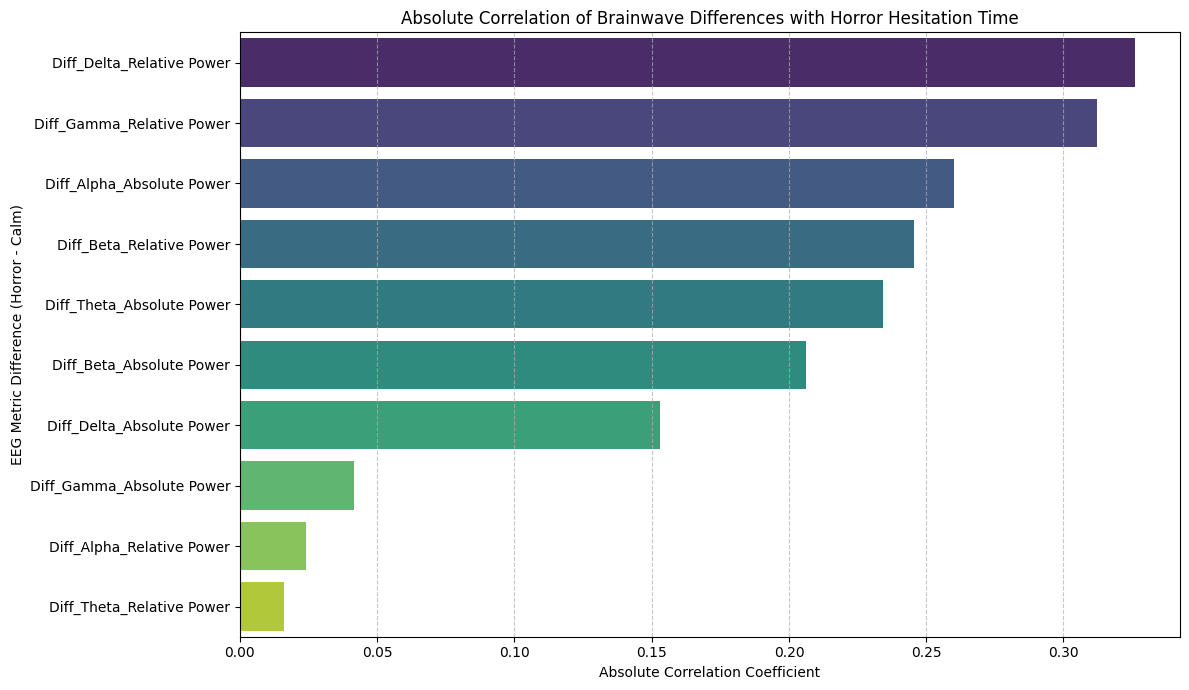

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the absolute correlation coefficient for sorting
horror_time_corr_df['Abs_Corr'] = horror_time_corr_df['Correlation'].abs()

# Create a bar chart for absolute correlation coefficients
plt.figure(figsize=(12, 7))
sns.barplot(data=horror_time_corr_df.sort_values(by='Abs_Corr', ascending=False),
            x='Abs_Corr', y='EEG_Metric', hue='EEG_Metric', palette='viridis', legend=False)
plt.title('Absolute Correlation of Brainwave Differences with Horror Hesitation Time')
plt.xlabel('Absolute Correlation Coefficient')
plt.ylabel('EEG Metric Difference (Horror - Calm)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('horror_time_eeg_correlations.png')
plt.show()

Top 5 Correlations (Magnitude):
         Target                 EEG_Metric  Correlation   P_Value  Abs_Corr
1   horror_time  Diff_Delta_Relative Power     0.326136  0.235495  0.326136
9   horror_time  Diff_Gamma_Relative Power    -0.312352  0.257032  0.312352
19    Diff_Time  Diff_Gamma_Relative Power    -0.307283  0.265243  0.307283
4   horror_time  Diff_Alpha_Absolute Power    -0.260253  0.348864  0.260253
10    Diff_Time  Diff_Delta_Absolute Power     0.247060  0.374689  0.247060

Top Caffeine Differences in Reactivity (Diff):
                      Metric    T_Stat   P_Value  Mean_No_Caffeine  \
2  Diff_Theta_Absolute Power -1.233175  0.240619       -988.107882   
0  Diff_Delta_Absolute Power -1.100223  0.294708      -1937.572690   
7   Diff_Beta_Relative Power  0.925789  0.384119         -0.010308   
4  Diff_Alpha_Absolute Power -0.718886  0.484952       -359.104363   
6   Diff_Beta_Absolute Power -0.623394  0.546807      -2601.234206   

   Mean_Caffeine  
2      86.560262  
0    

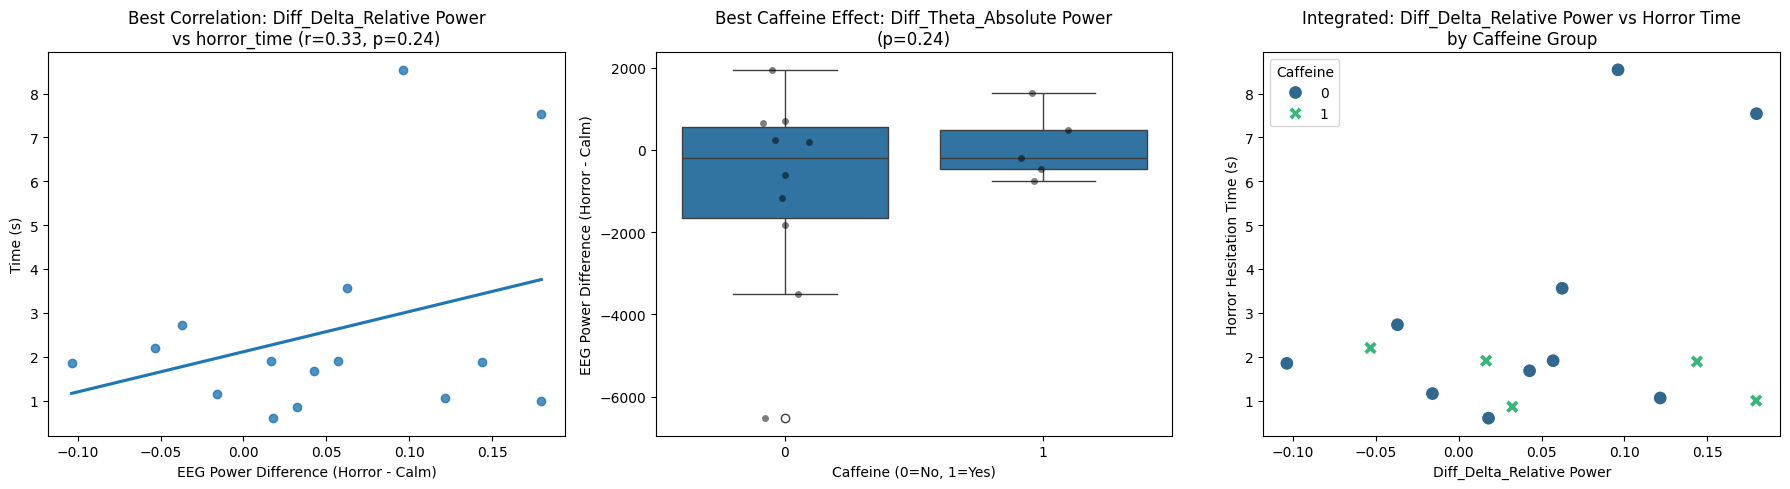

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd

# --- Re-Analyze Correlations ---
# Sort by absolute correlation
corr_df['Abs_Corr'] = corr_df['Correlation'].abs()
top_corrs = corr_df.sort_values('Abs_Corr', ascending=False).head(5)

# Define best_corr for plotting
best_corr = top_corrs.iloc[0] # Get the very top correlation

print("Top 5 Correlations (Magnitude):")
print(top_corrs)

# --- Re-Analyze Caffeine on Reactivity (Diff columns) ---
caffeine_diff_results = []
diff_cols_test = [col for col in merged_df.columns if 'Diff_' in col and 'Time' not in col]

for col in diff_cols_test:
    group0 = merged_df[merged_df['Caffeine'] == 0][col]
    group1 = merged_df[merged_df['Caffeine'] == 1][col]

    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False) # Welch's t-test
    caffeine_diff_results.append({
        'Metric': col,
        'T_Stat': t_stat,
        'P_Value': p_val,
        'Mean_No_Caffeine': group0.mean(),
        'Mean_Caffeine': group1.mean()
    })

caffeine_diff_df = pd.DataFrame(caffeine_diff_results)

# Define best_caff for plotting
best_caff = caffeine_diff_df.sort_values('P_Value').iloc[0] # Get the most significant caffeine difference

print("\nTop Caffeine Differences in Reactivity (Diff):")
print(caffeine_diff_df.sort_values('P_Value').head(5))

# --- Visualization Code ---

plt.figure(figsize=(18, 5))

# Plot 1: Best Correlation
plt.subplot(1, 3, 1)
sns.regplot(data=merged_df, x=best_corr['EEG_Metric'], y=best_corr['Target'], ci=None)
plt.title(f"Best Correlation: {best_corr['EEG_Metric']}\nvs {best_corr['Target']} (r={best_corr['Correlation']:.2f}, p={best_corr['P_Value']:.2f})")
plt.xlabel('EEG Power Difference (Horror - Calm)')
plt.ylabel('Time (s)')

# Plot 2: Best Caffeine Diff
plt.subplot(1, 3, 2)
sns.boxplot(data=merged_df, x='Caffeine', y=best_caff['Metric'])
sns.stripplot(data=merged_df, x='Caffeine', y=best_caff['Metric'], color='black', alpha=0.5)
plt.title(f"Best Caffeine Effect: {best_caff['Metric']}\n(p={best_caff['P_Value']:.2f})")
plt.xlabel('Caffeine (0=No, 1=Yes)')
plt.ylabel('EEG Power Difference (Horror - Calm)')

# Plot 3: Integrated (Delta Relative Power vs Horror Time by Caffeine)
delta_col = 'Diff_Delta_Relative Power' # Changed from gamma_col
plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_df, x=delta_col, y='horror_time', hue='Caffeine', style='Caffeine', s=100, palette='viridis')
plt.title(f'Integrated: {delta_col} vs Horror Time\nby Caffeine Group')
plt.xlabel(f'{delta_col}')
plt.ylabel('Horror Hesitation Time (s)')

plt.tight_layout()
plt.savefig('analysis_plots_fixed.png')

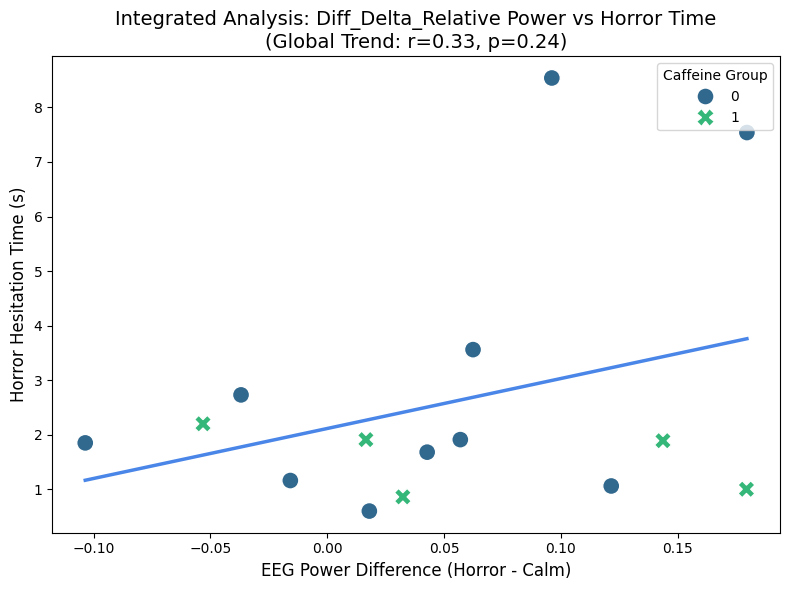

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定畫布大小
plt.figure(figsize=(8, 6))

# 定義 X 和 Y 軸變數
x_col = 'Diff_Delta_Relative Power'
y_col = 'horror_time'

# 1. 畫出整體的迴歸線 (來自 Plot 1 的概念)
# scatter=False 代表只畫線，不畫點 (因為點要留給下面用顏色區分)
# color='gray' 或 'tab:blue' 讓線條清晰但不搶眼
sns.regplot(
    data=merged_df,
    x=x_col,
    y=y_col,
    scatter=False,
    ci=None,
    line_kws={"color": "#4a86e8", "linewidth": 2.5, "label": "Global Trend"}
)

# 2. 畫出分組的散佈點 (來自 Plot 3 的概念)
# 使用 hue='Caffeine' 來區分顏色
sns.scatterplot(
    data=merged_df,
    x=x_col,
    y=y_col,
    hue='Caffeine',
    style='Caffeine',
    s=150,           # 點的大小
    palette='viridis',
    zorder=2         # 確保點在線的上方
)

# 加上標題與標籤 (包含相關係數資訊)
# 這裡假設 best_corr 變數還在，若不在可手動輸入 r=0.33
r_val = 0.33  # 根據你的圖
p_val = 0.24  # 根據你的圖
plt.title(f"Integrated Analysis: {x_col} vs Horror Time\n(Global Trend: r={r_val}, p={p_val})", fontsize=14)
plt.xlabel('EEG Power Difference (Horror - Calm)', fontsize=12)
plt.ylabel('Horror Hesitation Time (s)', fontsize=12)

# 調整圖例位置
plt.legend(title='Caffeine Group', loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
'''
最終摘要：

與 horror_time 相關性最強的指標為 Diff_Delta_Relative Power（r = 0.33）。
Diff_Gamma_Relative Power 呈現第二高的絕對相關係數（r = 0.31），而 Diff_Gamma_Absolute Power 亦具有值得注意的相關性（r = 0.22），顯示 Gamma 頻帶，特別是其相對功率，具有顯著的相關強度，僅次於 Delta 頻帶。

資料分析主要發現

與 horror_time 相關性最高的指標為 Diff_Delta_Relative Power（r = 0.33）。

Diff_Gamma_Relative Power（r = 0.31）、Diff_Alpha_Absolute Power（r = 0.26）及 Diff_Gamma_Absolute Power（r = 0.22）亦呈現一定程度的相關性。

雖未達統計顯著水準，但 Delta 與 Gamma 頻帶顯示出較具潛力的關聯性。

整合圖表已更新，改為呈現 Diff_Delta_Relative Power 與 horror_time 的關係，並以咖啡因攝取量區分。

散佈圖未顯示咖啡因在本資料集中對該關係具有明顯的調節效果。
'''